# SAXS NAF — Super-Resolution Querying

A neural implicit representation is a **continuous** field: once trained on the
native voxel grid, it can be queried at *any* resolution.  This notebook
demonstrates that for the NAF model — reconstruct a dataset from the registry,
then sample the trained SH-coefficient field on a `SUPERRES_FACTOR`× denser grid
over the *same* physical domain.

This only works for NAF (the SH/GK/FBP baselines produce a fixed discrete grid).

**What we compare** (per RSM direction, x/y/z slices):
- **`upsampled native`** — the native-resolution reconstruction, trilinearly
  upsampled to the target grid (what you'd get *without* an INR).
- **`NAF {factor}x`** — the field genuinely queried at the finer grid.

Both are rendered at the same target resolution so the difference is purely the
detail the INR recovers that interpolation cannot.

**Model persistence**: `saxs_naf_reconstruction` returns the trained model but the
cache previously stored only the `(X,Y,Z,C)` array.  We now `save_model` /
`load_model` the torch checkpoint (config + state_dict) so the field can be
re-queried without retraining.

In [1]:
import sys
sys.path.insert(0, '/myhome/smartt')

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from smartt.data_containers import get_dataset
from smartt.saxs_naf import saxs_naf_reconstruction
from smartt.saxs_naf.cache import save_recon, load_recon, save_model, load_model, list_cache
from smartt.saxs_naf.eval import evaluate_models, plot_rsm_direction

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


## Parameters
Edit this cell to change the run configuration.  `SUPERRES_FACTOR` is the
up-sampling factor (e.g. `2` or `4`).

In [2]:
DATASET = 'zenodo'      # one of: b411, zenodo, frogbone, fiber-synthetic

# Super-resolution
SUPERRES_FACTOR = 4     # query the trained field at this factor × native grid (2, 4, ...)

# RSM sampling / visualisation
ELL_MAX    = 8 
K_DIRS     = 30
ALPHA_DEG  = 45         # sample tilt angle (annotates missing-arc per direction)
HALF_SPACE = 'y'
K_SHOW     = 13         # RSM direction index to display (inspect missing_arcs_deg below)

# NAF reconstruction (must match the benchmark notebook to reuse cached recons)
NAF_PARAMS = dict(
    ell_max       = ELL_MAX,
    n_iterations  = 1000,
    lr            = 0.01,
    batch_size    = 100,
    reg_weight_sh = 1e-6,
    reg_weight_tv = 1e-5,
)

FORCE_RECOMPUTE = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 1. Load dataset from registry

In [3]:
ds        = get_dataset(DATASET)
cache_dir = ds.get_cache_dir()

print(f'Dataset  : {ds.name}')
print(f'DC types : {ds.available_dc_types()}')
print(f'Cache    : {cache_dir}')

partial_types = [t for t in ds.available_dc_types() if t != 'combined']
partial_dcs   = {t: ds.get_dc(t) for t in partial_types}
for t, dc in partial_dcs.items():
    print(f'{t:12s}  {len(dc.projections):4d} projections  vol={tuple(dc.geometry.volume_shape)}')

Dataset  : zenodo
DC types : ['main', 'remount', 'combined']
Cache    : /myhome/data/smartt/shared/results/zenodo_benchmark
INFO:Inner axis found in dataset base directory. This will override the default.
INFO:Outer axis found in dataset base directory. This will override the default.


INFO:Rotation matrix generated from inner and outer angles, along with inner and outer rotation axis vectors. Rotation and tilt angles assumed to be in radians.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
INFO:Inner axis found in dataset base directory. This will override the default.
INFO:Outer axis found in dataset base directory. This will override the default.
INFO:Rotation matrix generated from inner and outer angles, along with inner and outer rotation axis vectors. Rotation and tilt angles assumed to be in radians.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
INFO:Inner axis found in dataset base directory. This will override the default.
INFO:Outer axis found in dataset base directory. This will override the default.
INFO:Rotation matrix generated from inner and outer angles, along with inner and outer rotation axis vectors. Rotation and tilt angles assumed to be in radians.
INFO:Sample geometry loaded from 

## 2. Reconstruct (or reload) the NAF field + persist the model

The trained torch model is saved alongside the `(X,Y,Z,C)` array so it can be
re-queried at super-resolution without retraining.

In [4]:
def _naf_cache_params(dc_type):
    return dict(
        method='naf',
        dataset=ds.name,
        dc_type=dc_type,
        ell_max=NAF_PARAMS['ell_max'],
        n_iterations=NAF_PARAMS['n_iterations'],
        lr=NAF_PARAMS['lr'],
        batch_size=NAF_PARAMS['batch_size'],
        reg_weight_sh=NAF_PARAMS['reg_weight_sh'],
        reg_weight_tv=NAF_PARAMS['reg_weight_tv'],
    )


def get_naf_model_and_recon(train_dc, dc_type):
    """Return (model, native_coeffs).  Reloads from cache when available, else
    trains, then persists both the model checkpoint and the native array."""
    params = _naf_cache_params(dc_type)
    name   = f'naf_{ds.name}_{dc_type}'
    model  = None if FORCE_RECOMPUTE else load_model(cache_dir, name, params, device=device)
    recon  = None if FORCE_RECOMPUTE else load_recon(cache_dir, name, params)
    if model is not None and recon is not None:
        print(f'  [cache] naf  {dc_type}  model + recon {recon.shape}')
        return model, recon
    print(f'  [train] naf  {dc_type} …')
    res   = saxs_naf_reconstruction(train_dc, device=device, **NAF_PARAMS)
    model = res['model']
    recon = res['reconstruction'].numpy()
    save_recon(cache_dir, name, recon, params)
    save_model(cache_dir, name, model, params)
    print(f'  [done ] naf  {dc_type}  {recon.shape}  ({res["time"]:.0f}s)')
    return model, recon


models       = {}   # dc_type -> trained SaxsNafField
native_coeffs = {}  # dc_type -> (X, Y, Z, C) native reconstruction
for dc_type in partial_types:
    print(f'\n── {dc_type} ──')
    models[dc_type], native_coeffs[dc_type] = get_naf_model_and_recon(partial_dcs[dc_type], dc_type)


── main ──
  [cache] naf  main  model + recon (66, 66, 66, 45)

── remount ──
  [cache] naf  remount  model + recon (66, 66, 66, 45)


## 3. Query the field at super-resolution

`model.sample_super_resolution(factor)` evaluates the full SH field (no annealing
masks) on a `factor`× denser grid spanning the same physical domain.  For the
baseline we trilinearly upsample the native reconstruction to the same grid
(`align_corners=True` matches the shared-corner domain of the dense query).

In [5]:
def upsample_coeffs(coeffs, target_shape):
    """Trilinearly upsample an (X,Y,Z,C) coefficient field to target (X',Y',Z')."""
    t  = torch.from_numpy(np.asarray(coeffs)).permute(3, 0, 1, 2).unsqueeze(0).float()
    up = F.interpolate(t, size=tuple(target_shape), mode='trilinear', align_corners=True)
    return up.squeeze(0).permute(1, 2, 3, 0).contiguous().numpy()


superres_coeffs = {}   # dc_type -> (X',Y',Z',C)  genuine INR query
upsampled_coeffs = {}  # dc_type -> (X',Y',Z',C)  trilinear-upsampled native
for dc_type in partial_types:
    sr = models[dc_type].sample_super_resolution(SUPERRES_FACTOR).numpy()
    superres_coeffs[dc_type]  = sr
    upsampled_coeffs[dc_type] = upsample_coeffs(native_coeffs[dc_type], sr.shape[:3])
    print(f'{dc_type:12s}  native {native_coeffs[dc_type].shape[:3]}  →  {SUPERRES_FACTOR}x {sr.shape[:3]}')

main          native (66, 66, 66)  →  4x (264, 264, 264)
remount       native (66, 66, 66)  →  4x (264, 264, 264)


## 4. Compare per RSM direction (INR super-res vs upsampled native)

For a chosen direction `K_SHOW`, evaluate both fields into RSM volumes and show
orthogonal x/y/z slices side by side.  Inspect the printed `missing_arcs_deg` to
pick an interesting `K_SHOW` (large missing arc ⇒ harder direction).


main — missing-arc lengths:
  k=0:180°, k=1:67°, k=2:0°, k=3:0°, k=4:176°, k=5:135°, k=6:0°, k=7:0°, k=8:166°, k=9:163°, k=10:0°, k=11:0°, k=12:150°, k=13:176°, k=14:0°, k=15:0°, k=16:132°, k=17:180°, k=18:127°, k=19:0°, k=20:125°, k=21:179°, k=22:161°, k=23:109°, k=24:141°, k=25:177°, k=26:175°, k=27:162°, k=28:169°, k=29:179°


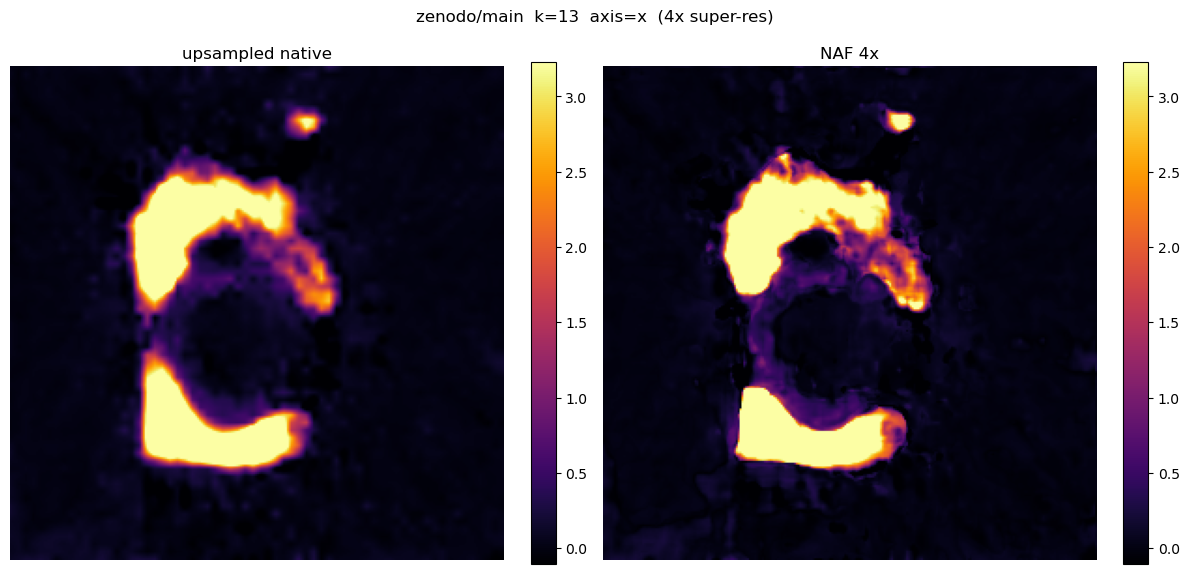

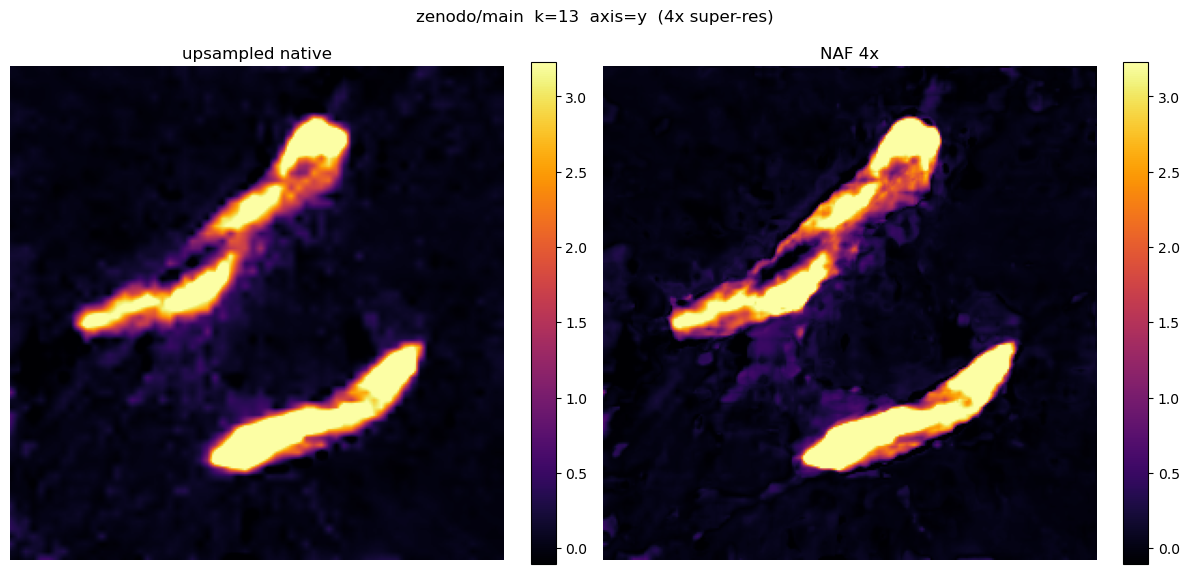

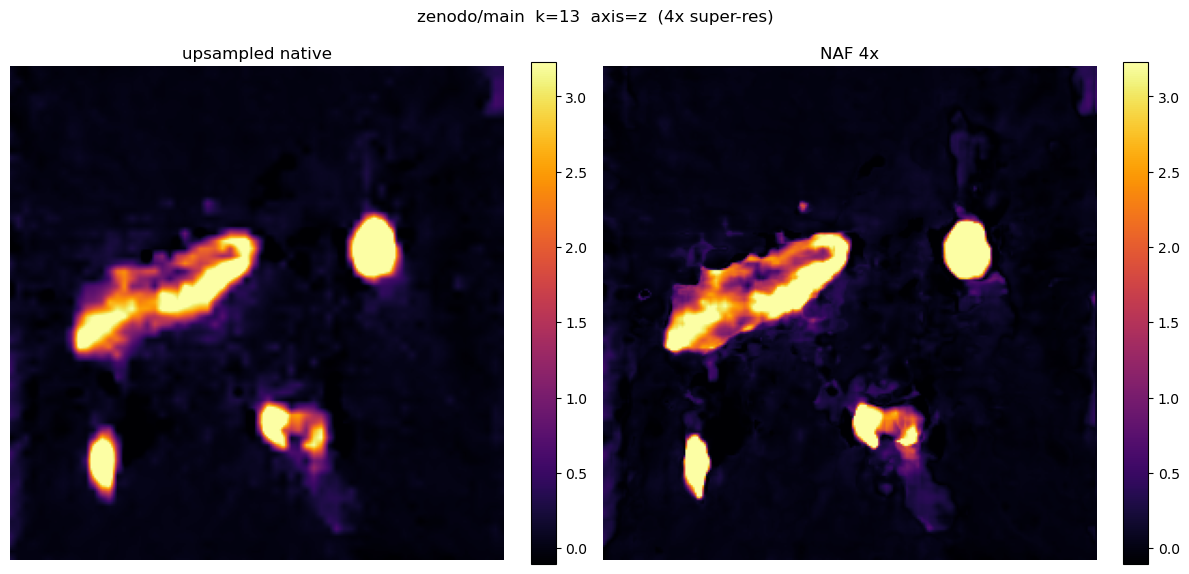


remount — missing-arc lengths:
  k=0:180°, k=1:67°, k=2:0°, k=3:0°, k=4:176°, k=5:135°, k=6:0°, k=7:0°, k=8:166°, k=9:163°, k=10:0°, k=11:0°, k=12:150°, k=13:176°, k=14:0°, k=15:0°, k=16:132°, k=17:180°, k=18:127°, k=19:0°, k=20:125°, k=21:179°, k=22:161°, k=23:109°, k=24:141°, k=25:177°, k=26:175°, k=27:162°, k=28:169°, k=29:179°


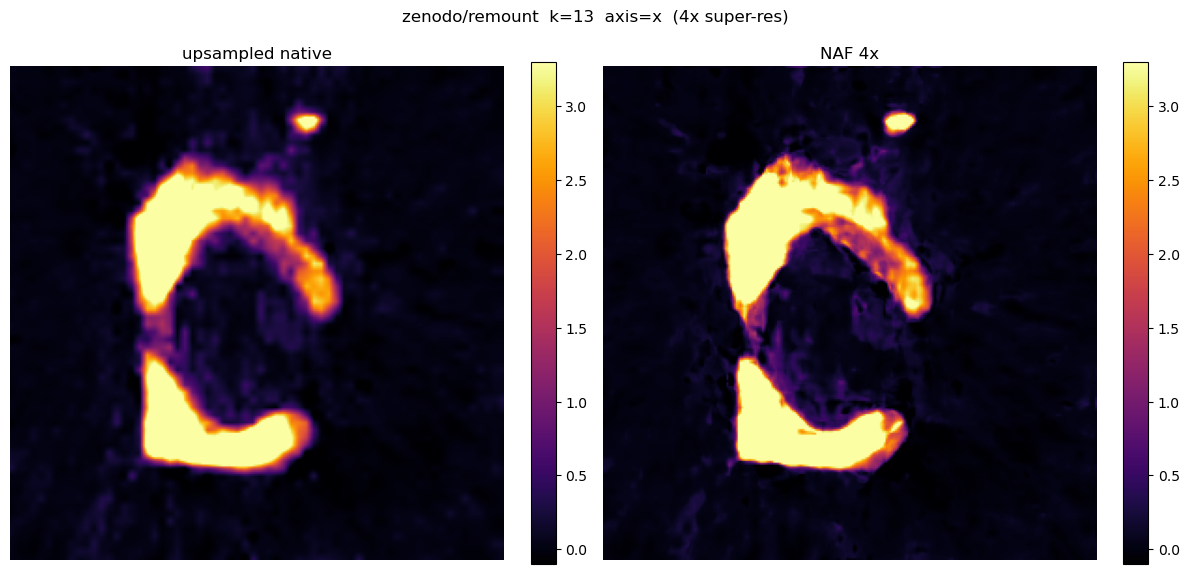

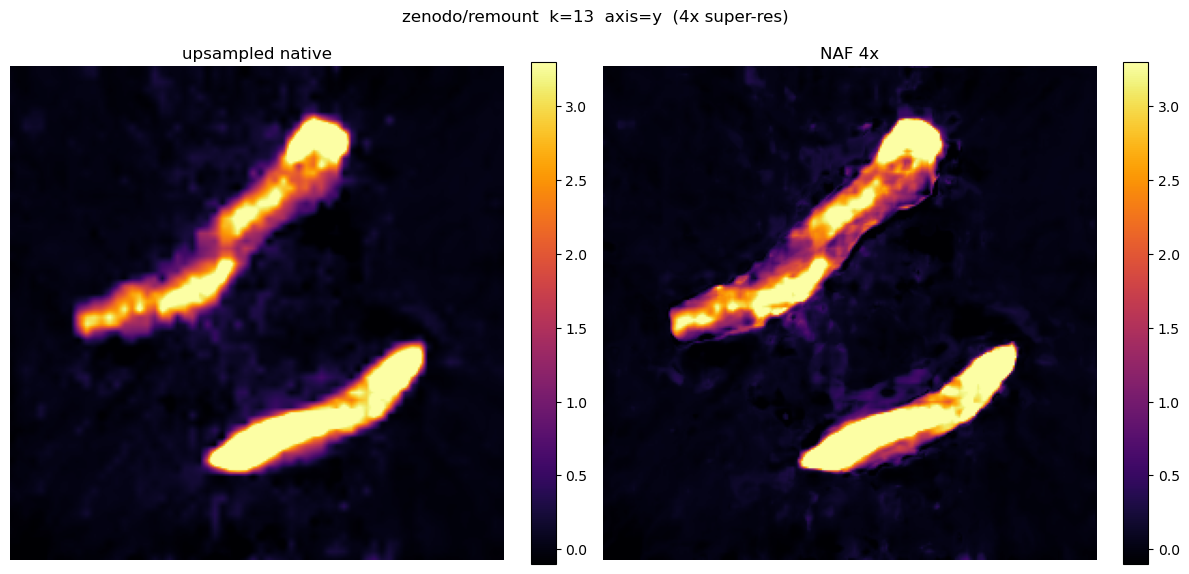

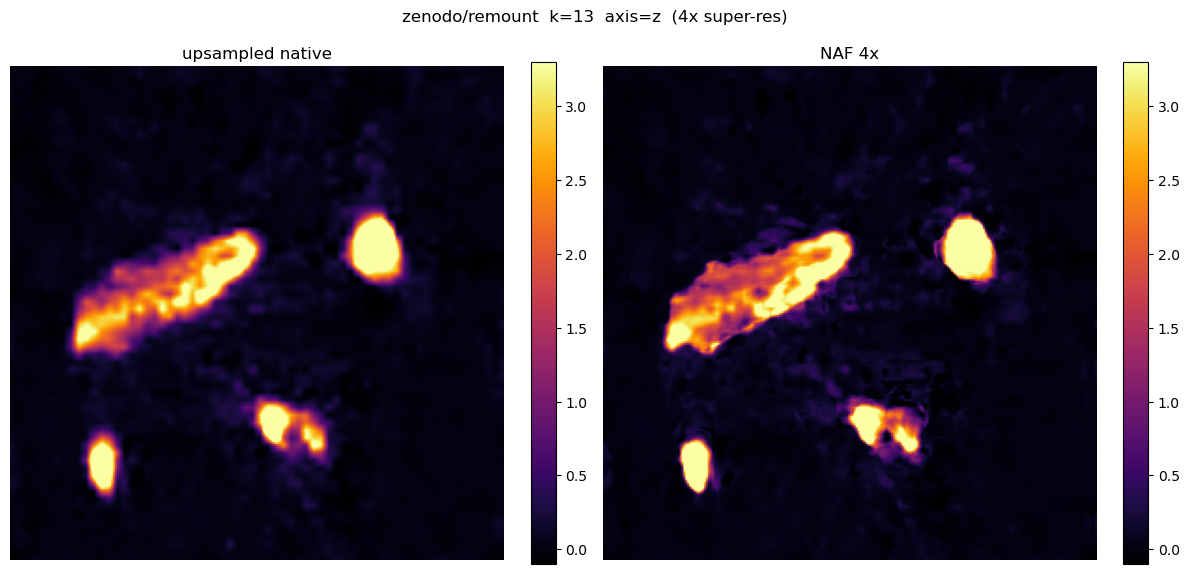

In [6]:
for dc_type in partial_types:
    cmp = evaluate_models(
        {'upsampled native': upsampled_coeffs[dc_type],
         f'NAF {SUPERRES_FACTOR}x': superres_coeffs[dc_type]},
        ell_max=ELL_MAX, K=K_DIRS, half_space=HALF_SPACE, alpha_deg=ALPHA_DEG,
    )
    if 'missing_arcs_deg' in cmp:
        arcs = ', '.join(f'k={k}:{a:.0f}°' for k, a in enumerate(cmp['missing_arcs_deg']))
        print(f'\n{dc_type} — missing-arc lengths:\n  {arcs}')
    for axis in ('x', 'y', 'z'):
        fig = plot_rsm_direction(cmp, k=K_SHOW, axis=axis)
        fig.suptitle(f'{ds.name}/{dc_type}  k={K_SHOW}  axis={axis}  ({SUPERRES_FACTOR}x super-res)')
        plt.show()

## 5. Cache inventory

In [7]:
for entry in list_cache(cache_dir):
    print(f"{entry['name']:30s}  hash={entry['hash']}  shape={entry.get('shape')}")

fbp_zenodo_main                 hash=673c5662  shape=(66, 66, 66, 45)
fbp_zenodo_remount              hash=6760a353  shape=(66, 66, 66, 45)
ground_truth                    hash=235162ae  shape=(66, 66, 66, 45)
mumott_gk_zenodo_combined       hash=1d296373  shape=(66, 66, 66, 45)
mumott_gk_zenodo_main           hash=db3457a5  shape=(66, 66, 66, 45)
mumott_gk_zenodo_remount        hash=957d56e8  shape=(66, 66, 66, 45)
mumott_sh_zenodo_combined       hash=80b13457  shape=(66, 66, 66, 45)
mumott_sh_zenodo_main           hash=4cb2bc5f  shape=(66, 66, 66, 45)
mumott_sh_zenodo_remount        hash=1aae2348  shape=(66, 66, 66, 45)
naf_zenodo_combined             hash=6f197669  shape=(66, 66, 66, 45)
naf_zenodo_main                 hash=6072a3f4  shape=(66, 66, 66, 45)
naf_zenodo_main                 hash=9611b316  shape=(66, 66, 66, 45)
naf_zenodo_remount              hash=2d679cf3  shape=(66, 66, 66, 45)
naf_zenodo_remount              hash=588def27  shape=(66, 66, 66, 45)
